# 03 - Flux Analysis

This notebook executes FBA and pFBA for the experimental dataset and augments the dataset by sweeping values of different substrates. GEM: iDT1294 from Tec-Campos et al., 2023.


## *Installation

In [ ]:
# Install cobrapy
!pip install -qq cobra catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.8/141.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 2.7 MB/s eta 0:00:00


In [ ]:
# Check installation
!pip show cobra

Name: cobra
Version: 0.30.0
Summary: COBRApy is a package for constraint-based modeling of metabolic networks.
Home-page: https://opencobra.github.io/cobrapy
Author: The cobrapy core development team.
Author-email: cobra-pie@googlegroups.com
License: LGPL-2.0-or-later OR GPL-2.0-or-later
Location: /usr/local/lib/python3.12/dist-packages
Requires: appdirs, depinfo, diskcache, future, httpx, numpy, optlang, pandas, pydantic, python-libsbml, rich, ruamel.yaml, swiglpk
Required-by: 


## *Mount drive

In [ ]:
import os
from pathlib import Path
from google.colab import drive

def mount_drive():
  drive.mount('/content/drive', force_remount=True)
  drive_folder = "metabolic_modelling/phb-optimization-rpalustris/"
  os.chdir('/content/drive/MyDrive/'+ drive_folder)
  global PROJECT_ROOT
  PROJECT_ROOT = Path(os.getcwd())

mount_drive()


Mounted at /content/drive


## *Load packages

In [ ]:
# Load packages

import logging
import cobra
from cobra import Reaction, Metabolite, Model, io
from cobra.io import (
    load_model, load_json_model, save_json_model,
    load_matlab_model, save_matlab_model,
    read_sbml_model, write_sbml_model
)

from cobra.flux_analysis import flux_variability_analysis, pfba

from cobra.util.solver import linear_reaction_coefficients

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
from itertools import product
import seaborn as sns
import json
import math
import copy
from tqdm import tqdm
import sys
import seaborn as sns
from scipy.stats import mannwhitneyu
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

## *Paths

In [ ]:
# Import path saved in src

import sys
sys.path.append(str(PROJECT_ROOT / "src"))
from src.paths import DATA_DIR, MODELS_DIR, PHB_MODEL_DIR, PHB_CHECKPOINTS_DIR, PHB_RESULTS_DIR, PHB_FIGURES_DIR, PHB_GEM_EXPERIMENTAL_DIR, PHB_GEM_AUGMENTATION_DIR, PHB_CATBOOST_DIR, PHB_PARETO_DIR


## *Load model

In [ ]:
# Load model

# Full path to the SBML file
phb_model_path = PHB_MODEL_DIR / "02_model_rpalustris_PHB_constrained.xml"

# Load model
model_phb = io.read_sbml_model(
    str(phb_model_path),
    use_fbc=False
)

print("Model loaded successfully")

Model loaded successfully


# Check model_phb  

In [ ]:
# Check model summary
model_phb.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
ac_e,EX_ac_e,0.2477,2,100.00%
photon690_e,EX_photon690_e,0.626,0,0.00%
phbg_c,SK_phbg_c,0.1238,0,0.00%
Metabolite,Reaction,Flux,C-Number,C-Flux
PHB_c,DM_PHB_c,-0.1238,4,99.92%
h2o_e,EX_h2o_e,-5E-05,0,0.00%
o2_e,EX_o2_e,-0.1238,0,0.00%
2obut_c,sink_2obut_c,-0.0001,4,0.08%


# *Copy model_phb2

In [ ]:
# model_phb2 copy from model_phb
model_phb2 = model_phb.copy()

# Opt: Load Buitrons medium constraints

Run in case constrainst were not set correctly in 02_set_model_constrains_phb.ipynb

In [ ]:
# Apply medium constraints from Montiel-Corona 2022.
def apply_media_from_excel(model, excel_path, close_exchanges=True):
    """
    Apply media constraints from an Excel file with columns:
    Reaction | LowerBound | UpperBound
    """

    media_df = pd.read_csv(excel_path)

    required_cols = {"Reaction", "LowerBound", "UpperBound"}
    if not required_cols.issubset(media_df.columns):
        raise ValueError(
            f"Excel file must contain columns: {required_cols}"
        )

    # Optionally close all exchanges first
    if close_exchanges:
        for rxn in model.exchanges:
            rxn.lower_bound = 0
            rxn.upper_bound = 1000

    # Apply media bounds
    for _, row in media_df.iterrows():
        rxn_id = row["Reaction"]

        if rxn_id not in model.reactions:
            raise KeyError(f"Reaction {rxn_id} not found in model")

        rxn = model.reactions.get_by_id(rxn_id)
        rxn.lower_bound = float(row["LowerBound"])
        rxn.upper_bound = float(row["UpperBound"])

    # Check reaction directly associated to PHB production
    EX_acetate_rxn = model.reactions.get_by_id("EX_ac_e")
    print(EX_acetate_rxn.bounds)
    print(EX_acetate_rxn.reaction)

    return model


## Apply Montiel-Corona 2022 medium

Run in case constrainst were not set correctly in 02_set_model_constrains_phb.ipynb

In [ ]:
# Apply media from excel function
excel_path = PHB_CHECKPOINTS_DIR / "02_model_phb_medium_montiel_buitron_2022.csv"
model_phb2 = apply_media_from_excel(model_phb2, excel_path)

(-0.2477, 1000.0)
ac_e <=> 


Name,iDT1294
Memory address,7f3560495c40
Number of metabolites,2124
Number of reactions,2721
Number of genes,1294
Number of groups,118
Objective expression,1.0*PHBS_syn - 1.0*PHBS_syn_reverse_8e587
Compartments,"c, u, p, e"


In [ ]:
# Print summary

model_phb2.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
ac_e,EX_ac_e,0.2477,2,100.00%
photon690_e,EX_photon690_e,0.626,0,0.00%
phbg_c,SK_phbg_c,0.1238,0,0.00%
Metabolite,Reaction,Flux,C-Number,C-Flux
PHB_c,DM_PHB_c,-0.1238,4,99.92%
h2o_e,EX_h2o_e,-5E-05,0,0.00%
o2_e,EX_o2_e,-0.1238,0,0.00%
2obut_c,sink_2obut_c,-0.0001,4,0.08%


## Opt: save metabolites and reactions

In [ ]:
# -----------------------
# Save reactions table
# -----------------------
rxn_data = []

for r in model_phb2.reactions:
    rxn_data.append({
        "id": r.id,
        "name": r.name,
        "equation": r.reaction,
        "lower_bound": r.lower_bound,
        "upper_bound": r.upper_bound,
        "genes": ";".join(g.id for g in r.genes),
    })

rxn_df = pd.DataFrame(rxn_data)
rxn_df.to_csv(PHB_CHECKPOINTS_DIR / "03_model_phb_reactions.csv", index=False)

# -----------------------
# Save metabolites table
# -----------------------
met_data = []

for m in model_phb2.metabolites:
    met_data.append({
        "id": m.id,
        "name": m.name,
        "formula": m.formula,
        "compartment": m.compartment,
        "charge": m.charge,
        "in_reactions": len(m.reactions),
    })

met_df = pd.DataFrame(met_data)
met_df.to_csv(PHB_CHECKPOINTS_DIR / "03_model_phb_metabolites.csv", index=False)


## Opt: Alernative Electron Sinks

Uncomment to simulate additional electron sinks. This could increase the competition for electron from different redox buffering pathways (e.g., PHB, H2, NO3, ATPM), thus decreasing PHB synthesis

In [ ]:
# Enable alternative electron carbon sinks to test electron leakage to other products and ATP maintainance cost

#h2_exchange = model_phb3.reactions.get_by_id('EX_h2_e') # H2 is the second electron sink of purple bacteria
#h2_exchange.lower_bound = 0  # Set the lower bound (uptake)
#h2_exchange.upper_bound = 10.0  # Set the upper boun (secretion)

#no3_exchange = model_phb3.reactions.get_by_id('EX_no3_e')
#no3_exchange.lower_bound = -1000.0  # Set the lower bound (uptake)
#no3_exchange.upper_bound = 0  # Set the upper boun (secretion)


#atpm_exchange = model_phb3.reactions.get_by_id('ATPM')
#atpm_exchange.lower_bound = 0  # Set the lower bound (uptake)
#atpm_exchange.upper_bound = 20  # Set the upper boun (secretion)



## Checkpoint: Save exchange bounds (medium conditions)

In [ ]:
# Save medium medium_montiel_buitron_2022_conservative_upperbound

# Collect bounds for all exchange reactions
rows = []
for rxn in model_phb2.exchanges:
    rows.append({
        "Reaction": rxn.id,
        "Name": rxn.name,
        "LowerBound": rxn.lower_bound,
        "UpperBound": rxn.upper_bound
    })

# Convert to DataFrame
medium_df = pd.DataFrame(rows)

# Save to Excel
medium_df.to_csv(PHB_CHECKPOINTS_DIR / "03_model_phb_medium.csv", index=False)

medium_df.head()


,Reaction,Name,LowerBound,UpperBound
0,EX_h2o_e,H2O exchange,0.0,1000.0
1,EX_o2_e,O2 exchange,0.0,1000.0
2,EX_co2_e,CO2 exchange,0.0,1000.0
3,EX_leu__L_e,L-Leucine exchange,0.0,0.0
4,EX_cobalt2_e,Co2+ exchange,0.0,1000.0


# *Checkpoint: Bounds RXN before FBA

In [ ]:
# Check BIOMASS__1 bounds
rxn = model_phb2.reactions.get_by_id('BIOMASS__1')
print(f"{rxn.id}: lower = {rxn.lower_bound}, upper = {rxn.upper_bound}") # bounds

# Check PHBS_syn bounds
rxn = model_phb2.reactions.get_by_id('PHBS_syn')
print(f"{rxn.id}: lower = {rxn.lower_bound}, upper = {rxn.upper_bound}") # bounds
print("PHBS_syn stoichiometry:", rxn.reaction)

BIOMASS__1: lower = 0.0, upper = 0.0
PHBS_syn: lower = 0.0, upper = 0.3978
PHBS_syn stoichiometry: 3hbcoa__R_c + phbg_c --> PHB_c + coa_c


# *One point FBA

Three test are executed with one data point from Montiel-Corona 2022, table 3).

Aim: to simulate three scenarios to assess PHB production from acetate.


1. Test 1: minimal acetate uptake magnitude to reach target PHB
2. Test 2: maximum PHB given fixed experimental acetate uptake
3. Test 3: global maximum PHB and required acetate
**bold text**
Results:

*   Acetate uptake rate =-0.12029
*   Experimental PHB rate = 0.02587


1.   Test 1: minimal acetate uptake magnitude for target PHB. Minimal acetate uptake magnitude (for PHB >= 0.025873): 0.051946 mmol·gDW⁻¹·h⁻¹ (flux = -0.051946)
→ PHB yield (exp1) = 0.498 mmol PHB per mmol acetate

2.   Test 2: maximum PHB for fixed acetate uptake. With acetate uptake fixed at 0.120290, max PHB = 0.060045 mmol·gDW⁻¹·h⁻¹
→ PHB yield (exp2) = 0.499 mmol PHB per mmol acetate

3. Test 3: global maximum PHB and required acetate. Maximum PHB flux = 0.120190 mmol·gDW⁻¹·h⁻¹
Required acetate uptake = 0.240580 mmol·gDW⁻¹·h⁻¹
→ PHB yield (exp3) = 0.500 mmol PHB per mmol acetate


Overall, GEM predicts twice the production observed experiementally.

In [ ]:
# Define function to retrieve fluxes from each optimization performed for each experiment

def get_flux(sol, rxn_id):
    if sol is None or sol.status != 'optimal':
        return float('nan')
    try:
        return float(sol.fluxes.get(rxn_id, float('nan')))
    except:
        return float('nan')

The following code uses real data from Montiel-Corona 2022 (First row in Table 3).



Reactions present:
EX_hxa_e: found
EX_fum_e: found
Specific uptake q_ac = 0.258345 mmol·gDW⁻¹·h⁻¹
Experimental PHB rate (q_phb) = 0.025873 mmol·gDW⁻¹·h⁻¹
Feasibility test (pFBA) - max PHB: 0.129072

--- Test 1: minimal acetate uptake (pFBA) ---
Minimal acetate uptake: 0.051946

--- Test 2: maximum PHB for fixed uptake (pFBA) ---
Max PHB: 0.129072

--- Test 3: global max PHB (pFBA) ---
Global Max PHB flux: 0.129072

--- Production envelope: PHB vs acetate uptake ---


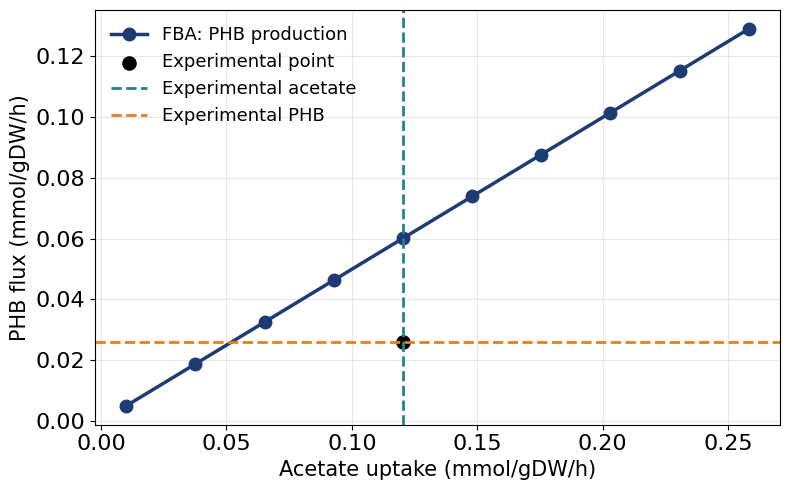

In [ ]:
# Find alternative reactions that may be relevant for carbon source uptake
r_hxa = model_phb2.reactions.get_by_id('EX_hxa_e')   # hexanoate exchange
r_fum = model_phb2.reactions.get_by_id('EX_fum_e')   # fumarate exchange

print("Reactions present:")
print(f"EX_hxa_e: {'found' if r_hxa else 'NOT found'}")
print(f"EX_fum_e: {'found' if r_fum else 'NOT found'}")

# === Identify key reactions ===
r_ac = model_phb2.reactions.get_by_id("EX_ac_e")     # acetate exchange
r_phb = model_phb2.reactions.get_by_id("PHBS_syn")   # PHB synthesis
r_biomass = model_phb2.reactions.get_by_id("BIOMASS__1")   # Biomass reaction

# === Experimental parameters ===
acetate_fed = 2260
acetate_removed_mgL = 1561
acetate_MW = 59.04
initial_biomass = 0.094
final_biomass = 1.367
time_h = 3 * 24
PHB_ww = 16

# --- Calculations ---
consumed_mgL = acetate_fed - acetate_removed_mgL
biomass_avg_gL = (final_biomass - initial_biomass) / 2
acetate_removed_mmolL = consumed_mgL / acetate_MW
acetate_mmol_per_L_per_h = acetate_removed_mmolL / time_h
q_ac = acetate_mmol_per_L_per_h / biomass_avg_gL

# PHB metrics
phb_mgL = 219
phb_MW = 86.0
phb_mmolL = phb_mgL / phb_MW
q_phb = (phb_mmolL / (final_biomass * time_h))

print(f"Specific uptake q_ac = {q_ac:.6f} mmol·gDW⁻¹·h⁻¹")
print(f"Experimental PHB rate (q_phb) = {q_phb:.6f} mmol·gDW⁻¹·h⁻¹")

# === Feasibility check with pFBA ===
model_phb2.objective = r_phb
r_ac.lower_bound = -q_ac
# Using pFBA instead of optimize()
model_phb2.objective = model_phb2.reactions.get_by_id(r_phb.id)
model_phb2.objective_direction = "max"   # or "min"
sol_test = pfba(model_phb2)
print(f"Feasibility test (pFBA) - max PHB: {sol_test.fluxes.get(r_phb.id, 0):.6f}")

# --- TEST 1: minimal acetate uptake magnitude via pFBA ---
print("\n--- Test 1: minimal acetate uptake (pFBA) ---")
m1 = model_phb2.copy()
m1.reactions.get_by_id(r_phb.id).lower_bound = q_phb
m1.objective = m1.reactions.get_by_id(r_ac.id)
m1.objective_direction = "max"   # or "min"
# Minimize uptake magnitude (maximize flux if it's negative)
sol_exp1 = pfba(m1)
if sol_exp1.status == "optimal":
    print(f"Minimal acetate uptake: {abs(sol_exp1.fluxes[r_ac.id]):.6f}")

# --- TEST 2: maximum PHB for fixed acetate uptake ---
print("\n--- Test 2: maximum PHB for fixed uptake (pFBA) ---")
m2 = model_phb2.copy()
m2.reactions.get_by_id(r_ac.id).lower_bound = -q_ac
m2.reactions.get_by_id(r_ac.id).upper_bound = -q_ac
m2.objective = r_phb
m2.objective_direction = "max"   # or "min"
sol_exp2 = pfba(m2)
print(f"Max PHB: {sol_exp2.fluxes[r_phb.id]:.6f}")

# --- TEST 3: global maximum PHB ---
print("\n--- Test 3: global max PHB (pFBA) ---")
m3 = model_phb2.copy()
m3.objective = r_phb
m3.objective_direction = "max"   # or "min"
sol_exp3 = pfba(m3)
print(f"Global Max PHB flux: {sol_exp3.fluxes[r_phb.id]:.6f}")


# --- PRODUCTION ENVELOPE: PHB vs acetate uptake ---
print("\n--- Production envelope: PHB vs acetate uptake ---")
uptake_mags = np.linspace(0.01, q_ac, 10)
phb_fluxes = []

m3 = model_phb2.copy()
m3.reactions.get_by_id(r_phb.id).lower_bound = 0.0
m3.reactions.get_by_id(r_phb.id).upper_bound = 1000.0
m3.objective = m3.reactions.get_by_id(r_phb.id)

uptake_negative = (model_phb2.reactions.get_by_id(r_ac.id).lower_bound < 0)

for up in uptake_mags:
    if uptake_negative:
        lb = -up
        ub = -up
    else:
        lb = up
        ub = up
    m3.reactions.get_by_id(r_ac.id).lower_bound = lb
    m3.reactions.get_by_id(r_ac.id).upper_bound = ub

    sol = m3.optimize()
    if sol.status == "optimal":
        phb = sol.fluxes.get(r_phb.id, 0.0)
        phb_fluxes.append(phb)
    else:
        phb_fluxes.append(np.nan)

# Plot PHB production curve only (no yield plot)

model_color = '#1F3B73'   # navy (model)
acetate_color = '#2A7F8E' # teal (experimental acetate)
phb_color = '#E67E22'     # muted orange (experimental PHB)
plt.figure(figsize=(8,5))

plt.plot(uptake_mags, phb_fluxes,
         'o-', markersize=9, linewidth=2.5, color=model_color,
         label='FBA: PHB production')

plt.scatter(0.120290, 0.025873,
            s=90, color='black',
            label='Experimental point')

plt.axvline(0.120290, linestyle='--', linewidth=2,  color=acetate_color,
            label='Experimental acetate')

plt.axhline(0.025873, linestyle='--', linewidth=2,  color=phb_color,
            label='Experimental PHB')

plt.xlabel('Acetate uptake (mmol/gDW/h)', fontsize=15)
plt.ylabel('PHB flux (mmol/gDW/h)', fontsize=15)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.legend(frameon=False, fontsize=13)

plt.grid(True, alpha=0.3)

plt.tight_layout()


for ext in ["pdf", "png", "tiff"]:
      plt.savefig(
          PHB_FIGURES_DIR / f"03_production_envelope_phb_vs_acetate.{ext}",
          dpi=300,
          bbox_inches="tight",
      )

plt.show()

# Checkpoint: Save all reactions after one point FBA

To snapshot reactions before performing optimization

In [ ]:
# Collect all reactions in a list of dicts
rxn_data = []
for rxn in model_phb2.reactions:
    rxn_data.append({
        "ReactionID": rxn.id,
        "Name": rxn.name,
        "Equation": rxn.build_reaction_string(use_metabolite_names=True),
        "LowerBound": rxn.lower_bound,
        "UpperBound": rxn.upper_bound,
        "ObjectiveCoeff": rxn.objective_coefficient,
        "Subsystem": rxn.subsystem
    })

# Convert to DataFrame
rxn_df = pd.DataFrame(rxn_data)

# Save to CSV
rxn_df.to_csv(PHB_CHECKPOINTS_DIR / "03_phb_model_all_reaction_bounds_right_after_one_point_fba.csv", index=False)

print("Saved complete reaction table to phb_model_all_reaction_bounds_right_after_one_point_fba.csv")


Saved complete reaction table to phb_model_all_reaction_bounds_right_after_one_point_fba.csv


# *Multiple points FBA and pFBA with Biutron's 2025 data

This code iterates over the operational values of experiments with acetate (mostly) from Monitel-Corona 2022. Iterate over first ~35 rows. Experiments with MCCA were not considered since the medium is not completely defined in most cases.

Note: Objective reaction is PHBS_syn. GEM does not allow optimizing PHBS_syn and have BIOMASS__1 >> 0 at the same time. Thus, PHB synthesis is modelled as a decoupled from biomass.



In [ ]:
# Load the CSV files
Buitron_data_path = DATA_DIR / "Buitron2025_dataset_corrected.csv"

# Define df
df_buitron = pd.read_csv(Buitron_data_path)


# Define function to get top reaction IDs

def get_top_reaction_ids(fluxes, top_n=20, exclude_rxns=None):
    if exclude_rxns is None:
        exclude_rxns = set()
    fluxes_filt = fluxes.drop(labels=exclude_rxns, errors="ignore")
    return fluxes_filt.abs().sort_values(ascending=False).head(top_n).index.tolist()

# ============================================================
# CONSTANTS
# ============================================================

PHB_MW = 86.0
ACETATE_MW = 59.04
BUTYRATE_MW = 88.11
PROPIONATE_MW = 74.08
LACTATE_MW = 90.08
SUCCINATE_MW = 118.09
BICARBONATE_MW = 61.016
N_MW = 14.01

COD_TO_ACETATE_RATIO = 1.066
FALLBACK_TIME_H = 72.0

TOP_N = 20
EXCLUDE_RXNS = {"BIOMASS__1", "PHBS_syn"} #"ATPM"

PHB_SYN_UB_VALUES = [0.3978, 1.0, 1000] # 0.0167

for PHB_SYN_UB in PHB_SYN_UB_VALUES:

  print(f"PHB_SYN_UB_VALUE:{PHB_SYN_UB}")
  PHB_SYN_TAG = f"{PHB_SYN_UB:g}"  # used for filenames

  # ============================================================
  # LOAD DATA
  # ============================================================

  df = df_buitron.copy().iloc[1:32].reset_index(drop=True)
  print(df.head())
  #print("Dataset shape:", df.shape)

  # ============================================================
  # MEDIUM DEFAULTS
  # ============================================================

  medium_bounds = {
      "EX_ac_e": 0.2477,
      "EX_nh4_e": 1,
      "EX_hco3_e": 0,
  }

  SUB_TO_RXN = {
      "ace": "EX_ac_e",
      "lac": "EX_lac__L_e",
      "ppa": "EX_ppa_e",
      "but": "EX_but_e",
      "ibt": "EX_ibt_e",
      "mal": "EX_mal__L_e",
      "hxa": "EX_hxa_e",
      "oct": "EX_octa_e",
  }

  SUBSTRATE_COLS = list(SUB_TO_RXN.keys())

  # ============================================================
  # MAIN LOOP
  # ============================================================

  results = []
  top20_rxn_sets = []
  top20_flux_rows = []
  top20_rxn_sets_pfba = []
  top20_flux_rows_pfba = []

  for i, row in df.iterrows():
      print(f"\n=== Row {i+1} ===")
      m = model_phb2.copy()

      # Apply medium
      for rid, ub in medium_bounds.items():
          if rid in m.reactions:
              rxn = m.reactions.get_by_id(rid)
              rxn.lower_bound = -ub
              rxn.upper_bound = 0.0

      # Time
      t_days = row.get("Time (d)", np.nan)
      t_h = FALLBACK_TIME_H if pd.isna(t_days) or t_days <= 0 else float(t_days) * 24

      # Biomass
      biomass_mgL = row.get("Biomass (mg dw/L)", np.nan)
      biomass_gL = biomass_mgL / 1000 if not pd.isna(biomass_mgL) and biomass_mgL > 0 else np.nan

      # Experimental PHB flux
      phb_mgL = row.get("PHB (mg/L)", np.nan)
      q_phb_exp = (
          (phb_mgL / PHB_MW) / (biomass_gL * t_h)
          if not pd.isna(phb_mgL) and not pd.isna(biomass_gL)
          else np.nan
      )

      # Initialize feeds
      q_sub = np.nan
      q_nh4 = np.nan
      q_NaHCO3_L = np.nan
      sub_rxn = None

      # Substrate
      COD_gL = row.get("g substrate COD/L", np.nan)
      substrate = str(row.get("Type of substrate", "")).lower()

      if not pd.isna(COD_gL) and not pd.isna(biomass_gL):
          cod_mgL = COD_gL * 1000
          if "but" in substrate:
              mmolL = cod_mgL / BUTYRATE_MW
              sub_rxn = "EX_but_e"
          elif "ppa" in substrate:
              mmolL = cod_mgL / PROPIONATE_MW
              sub_rxn = "EX_ppa_e"
          elif "lac" in substrate:
              mmolL = cod_mgL / LACTATE_MW
              sub_rxn = "EX_lac__L_e"
          elif "succ" in substrate:
              mmolL = cod_mgL / SUCCINATE_MW
              sub_rxn = "EX_succ_e"
          else:
              mmolL = cod_mgL / COD_TO_ACETATE_RATIO / ACETATE_MW
              sub_rxn = "EX_ac_e"

          q_sub = mmolL / (biomass_gL * t_h)

      if sub_rxn in m.reactions and not pd.isna(q_sub):
          rxn = m.reactions.get_by_id(sub_rxn)
          rxn.lower_bound = rxn.upper_bound = -q_sub

      # Nitrogen
      mgN_L = row.get("mg N/L", np.nan)
      if not pd.isna(mgN_L) and not pd.isna(biomass_gL):
          q_nh4 = (mgN_L / N_MW) / (biomass_gL * t_h)
          if "EX_nh4_e" in m.reactions:
              m.reactions.get_by_id("EX_nh4_e").lower_bound = -q_nh4

      # Bicarbonate
      gNaHCO3_L = row.get("g NaHCO3/L", np.nan)
      if not pd.isna(gNaHCO3_L) and not pd.isna(biomass_gL):
          q_NaHCO3_L = (gNaHCO3_L / BICARBONATE_MW) / (biomass_gL * t_h) * 1000
          if "EX_hco3_e" in m.reactions:
              m.reactions.get_by_id("EX_hco3_e").lower_bound = -q_NaHCO3_L


      rxn = m.reactions.get_by_id("PHBS_syn")
      rxn.lower_bound = 0
      rxn.upper_bound = PHB_SYN_UB
      # Objective
      m.objective = rxn

      print(rxn.bounds)
      print(rxn.reaction)

      # Optimize FBA
      sol = m.optimize()
      fluxes = sol.fluxes if sol.status == "optimal" else pd.Series(dtype=float)

      # Optimize pFBA
      sol_pfba = pfba(m)
      fluxes_pfba = sol_pfba.fluxes

      # FVA
      PHB_REACTIONS = [
          "PHBS_syn",
          "ACACT1r",
          "ACACCT",
          "AACOAR_syn",
          "HACD1_2",
          "HACD1",
          "HACD1i",
          "KAT1"
      ]

      # Initialize dict to store FVA spans
      fva_spans = {rxn: np.nan for rxn in PHB_REACTIONS}

      # FBA reactions

      if sol.status == "optimal":
          # Fraction of optimum (95%)
          fva = flux_variability_analysis(m, PHB_REACTIONS, fraction_of_optimum=0.95)

          # Compute span for each PHB reaction
          for rxn in PHB_REACTIONS:
              fva_spans[rxn] = fva.loc[rxn, "maximum"] - fva.loc[rxn, "minimum"]

          top_rxns = get_top_reaction_ids(
                  fluxes,
                  top_n=TOP_N,
                  exclude_rxns=EXCLUDE_RXNS
              )
          top20_rxn_sets.append(set(top_rxns))

          top_flux_dict = fluxes[top_rxns].to_dict()
          top20_flux_rows.append(top_flux_dict)

      # pFBA reactions

      if sol_pfba.status == "optimal":
          top_rxns_pfba = get_top_reaction_ids(
              fluxes_pfba,
              top_n=TOP_N,
              exclude_rxns=EXCLUDE_RXNS
          )

          top20_rxn_sets_pfba.append(set(top_rxns_pfba))

          top_flux_dict_pfba = fluxes[top_rxns_pfba].to_dict()
          top20_flux_rows_pfba.append(top_flux_dict_pfba)


      # Now you can add these spans to your row dictionary
      row_out = {
          "Row": i + 1,
          "Time_h": t_h,
          "Biomass_gL": biomass_gL,
          "PHB_exp_flux": q_phb_exp,
          "PHB_model_flux": fluxes.get("PHBS_syn", np.nan),
          "PHB_model_flux_pfba": fluxes_pfba.get("PHBS_syn", np.nan),
          # Store FVA spans
          "PHB_fva_span": fva_spans["PHBS_syn"],  # keep original key for backward compatibility
      }

      # Add spans for all other PHB reactions
      for rxn in PHB_REACTIONS:
          row_out[f"{rxn}_fva_span"] = fva_spans[rxn]

      # Example for uptake/constrained fluxes (unchanged)
      row_out.update({
          "nh4_sup": q_nh4,
          "nh4_con": fluxes.get("EX_nh4_e", np.nan),
          "nh4_con_pfba": fluxes_pfba.get("EX_nh4_e", np.nan),
          "hco3_sup": q_NaHCO3_L,
          "hco3_con": fluxes.get("EX_hco3_e", np.nan),
          "hco3_con_pfba": fluxes_pfba.get("EX_hco3_e", np.nan),
      })


      for sub in SUBSTRATE_COLS:
          rxn_id = SUB_TO_RXN[sub]
          row_out[f"{sub}_sup"] = -q_sub if sub_rxn == rxn_id and not pd.isna(q_sub) else 0.0
          row_out[f"{sub}_con"] = fluxes.get(rxn_id, 0.0)
          row_out[f"{sub}_con_pfba"] = fluxes_pfba.get(rxn_id, 0.0)

      results.append(row_out)

  # ============================================================
  # SAVE RESULTS
  # ============================================================

  results_df = pd.DataFrame(results)
  print(results_df.head())
  results_df.to_csv(PHB_CHECKPOINTS_DIR / f"03_FBA_results_summary_steady_state_{PHB_SYN_TAG}.csv", index=False)

  df_out = pd.concat([df.reset_index(drop=True), results_df], axis=1)
  df_out.to_csv(PHB_CHECKPOINTS_DIR / f"03_Buitron_dataset_augmented_with_FBA_PHB_{PHB_SYN_TAG}.csv", index=False)

  # ============================================================
  # TOP-20 FBA REACTIONS INTERSECTION & UNION
  # ============================================================

  top20_intersection = set.intersection(*top20_rxn_sets) if top20_rxn_sets else set()
  top20_union = set.union(*top20_rxn_sets) if top20_rxn_sets else set()

  X_top_fluxes = pd.DataFrame(top20_flux_rows).fillna(0.0)
  X_top_fluxes = X_top_fluxes[list(top20_intersection)]
  X_top_fluxes.to_csv(PHB_CHECKPOINTS_DIR / f"03_Buitron_dataset_top20_intersection_fluxes_{PHB_SYN_TAG}.csv", index=False)
  X_top_fluxes_union = pd.DataFrame(top20_flux_rows).fillna(0.0)
  X_top_fluxes_union = X_top_fluxes_union[list(top20_union)]
  X_top_fluxes_union.to_csv(
    PHB_CHECKPOINTS_DIR / f"03_Buitron_dataset_top20_union_fluxes_{PHB_SYN_TAG}.csv",
    index=False
  )

  # ============================================================
  # TOP-20 pFBA REACTIONS INTERSECTION & UNION
  # ============================================================

  top20_intersection_pfba = set.intersection(*top20_rxn_sets_pfba) if top20_rxn_sets_pfba else set()
  top20_union_pfba = set.union(*top20_rxn_sets_pfba) if top20_rxn_sets_pfba else set()

  X_top_fluxes_pfba = pd.DataFrame(top20_flux_rows_pfba).fillna(0.0)
  X_top_fluxes_pfba = X_top_fluxes_pfba[list(top20_intersection_pfba)]
  X_top_fluxes_pfba.to_csv(PHB_CHECKPOINTS_DIR / f"03_Buitron_dataset_top20_intersection_fluxes_pfba_{PHB_SYN_TAG}.csv", index=False)
  X_top_fluxes_union_pfba = pd.DataFrame(top20_flux_rows_pfba).fillna(0.0)
  X_top_fluxes_union_pfba = X_top_fluxes_union_pfba[list(top20_union_pfba)]
  X_top_fluxes_union_pfba.to_csv(
    PHB_CHECKPOINTS_DIR / f"03_Buitron_dataset_top20_union_fluxes_pfba_{PHB_SYN_TAG}.csv",
    index=False
  )

print("\nDONE — steady-state FBA with biomass-only scaling + top-20 fba and pfba reactions stored.")
print("\nALL RUNS DONE")


# *Histogram and Wordcloud with top K reactions

The reactions with the largest flux magnitudes in each FBA/pFBA run were ploted as histograms and wordclod


Processing PHB_SYN_UB = 0.3978


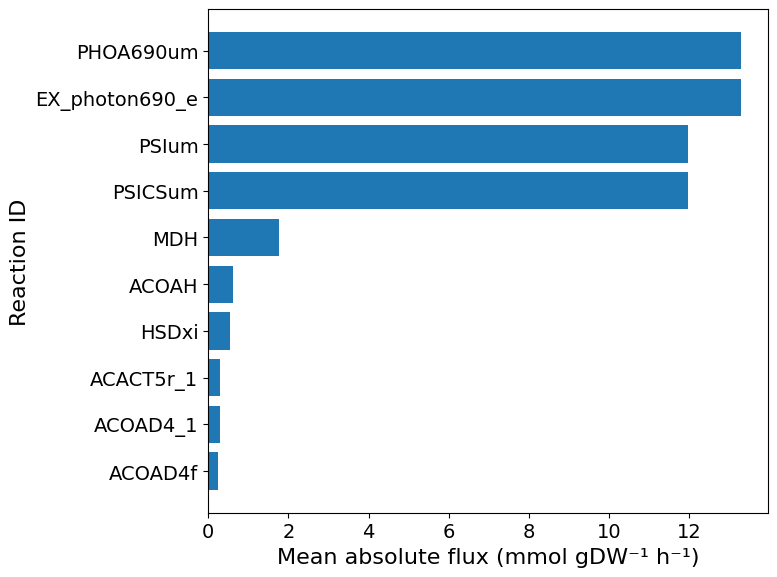

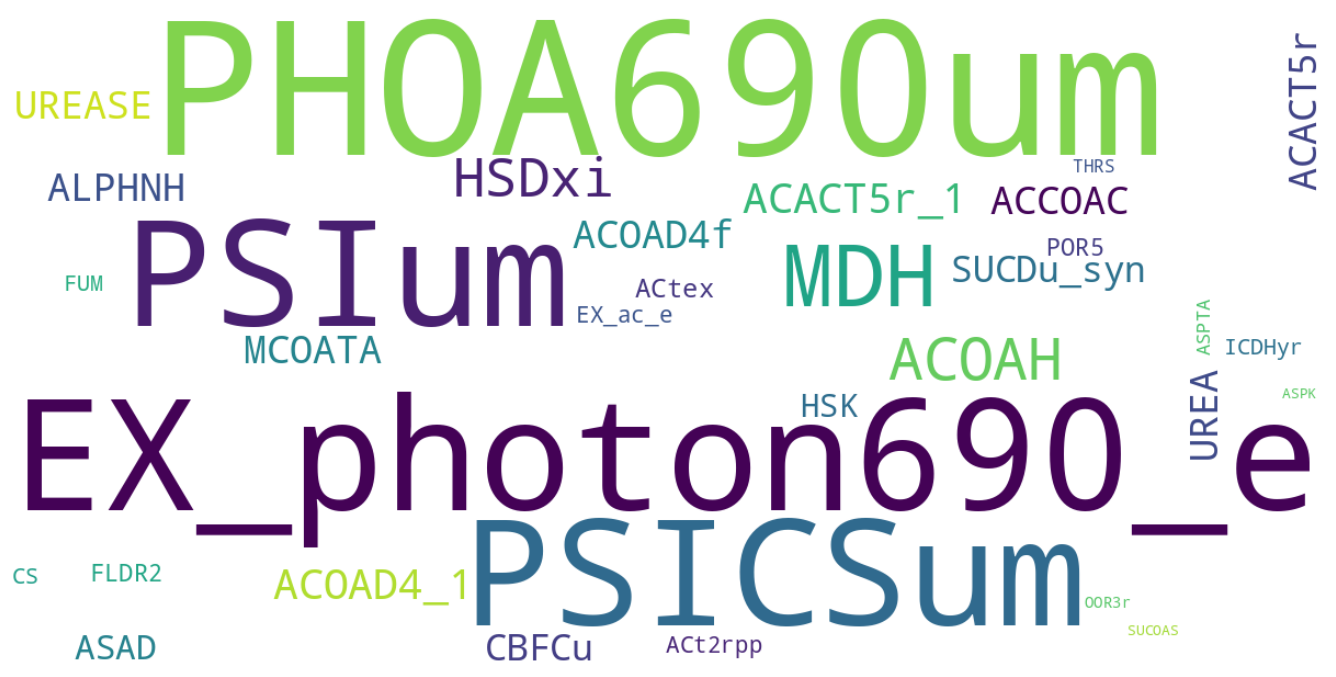


Processing PHB_SYN_UB = 1000.0


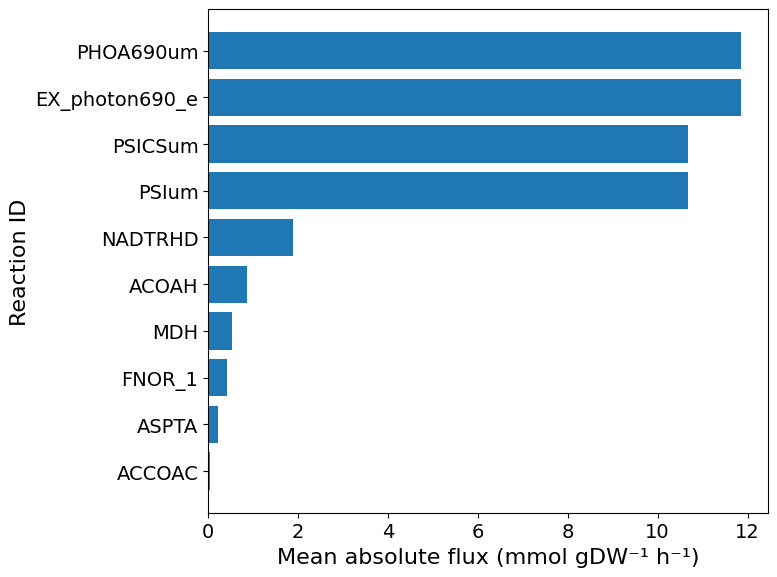

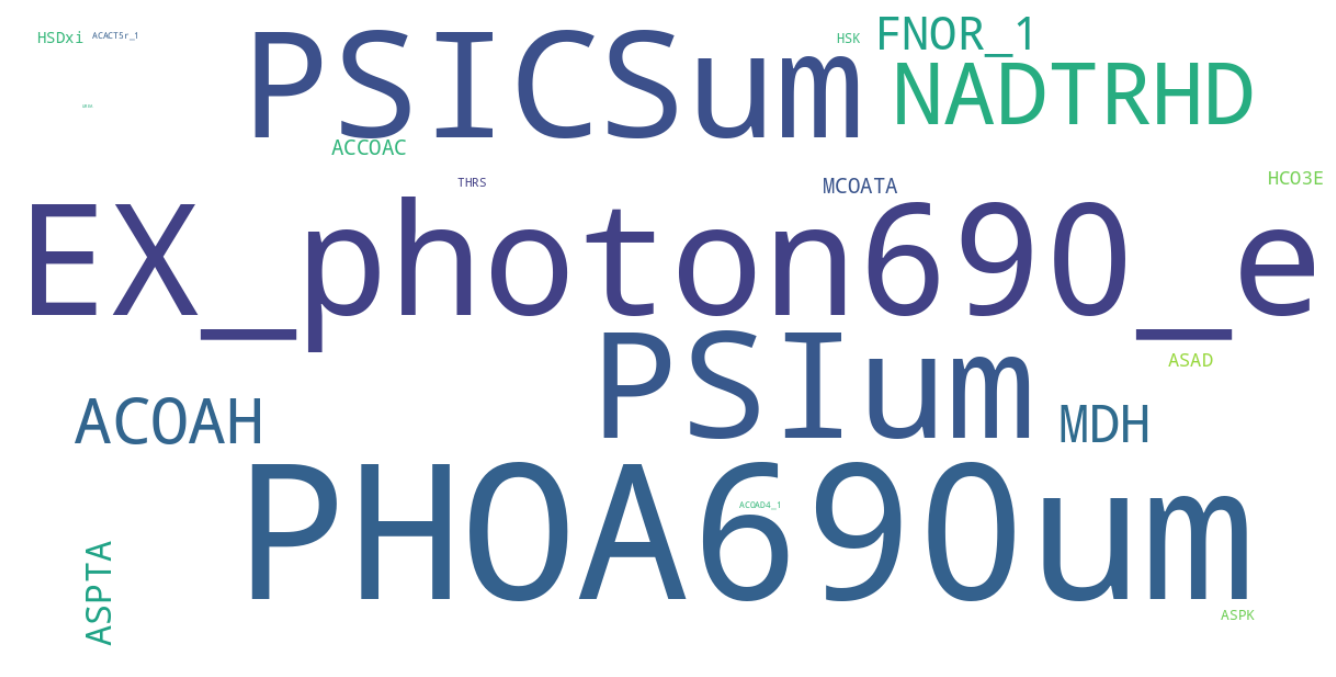

In [ ]:
from wordcloud import WordCloud
from collections import Counter

TOP_K = 10
PHB_SYN_UB_VALUES = [0.3978, 1000.0] #[0.0167, 1.0]



for PHB_SYN_UB in PHB_SYN_UB_VALUES:

    print(f"\nProcessing PHB_SYN_UB = {PHB_SYN_UB}")
    PHB_SYN_TAG = f"{PHB_SYN_UB:g}"

    # --------------------------------------------------
    # 1. Load Top-20 intersection fluxes
    # --------------------------------------------------
    df = pd.read_csv(
        PHB_CHECKPOINTS_DIR / f"03_Buitron_dataset_top20_union_fluxes_pfba_{PHB_SYN_TAG}.csv"
    )

    # rows   -> FBA runs
    # columns-> reactions (top-20 intersection)
    n_runs = df.shape[0]

    # --------------------------------------------------
    # 2. Flux-weighted, normalized reaction relevance
    # --------------------------------------------------
    flux_scores = (
        df.abs()
          .sum(axis=0)          # sum |flux| across runs
          .div(n_runs)          # normalize by number of runs
          .sort_values(ascending=False)
    )

    score_df = (
        flux_scores
        .reset_index()
        .rename(columns={"index": "reaction_id", 0: "mean_abs_flux"})
    )

    score_df_top = score_df.head(TOP_K)

    # ==================================================
    # PART A — REACTION-LEVEL PLOTS
    # ==================================================

    # --------------------------------------------------
    # Histogram (reactions)
    # --------------------------------------------------
    plt.rcParams.update({'font.size': 14})
    plt.figure(figsize=(8, 6))
    plt.barh(
        score_df_top["reaction_id"][::-1],
        score_df_top["mean_abs_flux"][::-1]
    )
    plt.xlabel("Mean absolute flux (mmol gDW⁻¹ h⁻¹)", fontsize= 16)
    plt.ylabel("Reaction ID", fontsize= 16)
    #plt.title(f"Flux-weighted reaction relevance")
    plt.tight_layout()

    for ext in ["pdf", "png", "tiff"]:
        plt.savefig(
            PHB_FIGURES_DIR / f"03_histogram_flux_weighted_reactions_NO_aug_PFBA_PHB_SYN_UB_{PHB_SYN_TAG}.{ext}",
            dpi=300,
            bbox_inches="tight",
    )
    plt.show()

    # --------------------------------------------------
    # Wordcloud (reactions)
    # --------------------------------------------------
    wc_rxn = WordCloud(
        width=1200, height=600,
        background_color="white",
        max_words=100
    ).generate_from_frequencies(flux_scores.to_dict())

    plt.figure(figsize=(14, 7))
    plt.imshow(wc_rxn, interpolation="bilinear")
    plt.axis("off")
    plt.tight_layout()

    for ext in ["pdf", "png", "tiff"]:
        plt.savefig(
            PHB_FIGURES_DIR / f"03_wordcloud_flux_weighted_reactions_NO_aug_PFBA_PHB_SYN_UB_{PHB_SYN_TAG}.{ext}",
            dpi=300,
            bbox_inches="tight",
    )
    plt.show()


In [ ]:
# Reaction to Subsystem mapping (from GEM)
#This output is not so clean since the subsystems are not named consistenly

#flux_subsystem = {
#    rxn.id: rxn.subsystem if rxn.subsystem else "Other"
#    for rxn in model_phb2.reactions
#}

# Check reaction relevance using flux-weighted normalized data

In [ ]:
df = pd.read_csv(
        PHB_CHECKPOINTS_DIR / f"03_Buitron_dataset_top20_union_fluxes_1000.csv"
    )

n_runs = df.shape[0]

# --------------------------------------------------
# 2. Flux-weighted, normalized reaction relevance
# --------------------------------------------------
flux_scores = (
  df.abs()
    .sum(axis=0)          # sum |flux| across runs
    .div(n_runs)          # normalize by number of runs
    .sort_values(ascending=False)
)

score_df = (
  flux_scores
  .reset_index()
  .rename(columns={"index": "reaction_id", 0: "mean_abs_flux"})
)

score_df_top = score_df.head(TOP_K)

score_df_top


,reaction_id,mean_abs_flux
0,PHOA690um,11.862391
1,EX_photon690_e,11.862391
2,PSIum,10.676152
3,PSICSum,10.676152
4,CBFCum,4.704224
5,NDH_1_1_um_copy1,3.990834
6,ATPM,2.905540
7,ATPSum,2.670145
8,PGK,2.177544
9,GAPDi_nadp,2.177544


# Opt: List of reactions associated to acetyl-coa, NAD+, ferrodoxin

Find key reactions for PHB production and redox state (e.g., associated to acetyl-coa, nad, ferrodoxin).

In [ ]:
# 1A: list open uptake exchanges (possible carbon donors)
open_uptakes = [(ex.id, ex.lower_bound) for ex in model_phb2.exchanges if ex.lower_bound < 0]
print("Open uptakes (id, lb):", open_uptakes)

# 1B: top consumers of acetyl-CoA and top NAD(P)H producers/consumers
sol = model_phb2.optimize()
# filter by strings may be coarse; adapt IDs to your model
for rxn in model_phb2.reactions:
    if 'accoa' in str(rxn.reaction).lower() or 'acetyl-coa' in (rxn.name or '').lower():
        print(rxn.id, sol.fluxes.get(rxn.id,0.0), rxn.reaction)
# redox drivers
redox = []
for rxn in model_phb2.reactions:
    s = str(rxn.reaction).lower()
    if 'nad' in s or 'nadp' in s or 'fd' in s or 'ferredoxin' in s:
        redox.append((rxn.id, sol.fluxes.get(rxn.id,0.0), rxn.reaction))
redox_sorted = sorted(redox, key=lambda x: abs(x[1]), reverse=True)[:30]
print("Top redox reactions:")
for r in redox_sorted:
    print(r)


# Opt: Report flux of key reactions

Modify reactions of interest

In [ ]:
# Check key fluxes of enzymes involved in phb and biomas production by acetate uptake

# Reactions:
# Acetoacetyl CoA reductase
# Acetyl-CoA C-acetyltransferase
# Glucose 6-phosphate dehydrogenase
# ATP maintenance requirement
# PHB synthetasa

key = ['BIOMASS__1','EX_ac_e','PHBS_syn','AACOAR_syn','ACACT1r','PDH','G6PDH2r','ATPM']
for r in key:
    if r in model_phb2.reactions:
        print(r, "bounds", model_phb2.reactions.get_by_id(r).bounds, "flux", sol.fluxes.get(r, None))
    else:
        print(r, "not in model")


BIOMASS__1 bounds (0.0, 2.0) flux 0.0
EX_ac_e bounds (-0.12029008061355913, 1000) flux -0.24058016122711826
PHBS_syn bounds (0.0, 999999.0) flux 0.12019008061356057
AACOAR_syn bounds (0.0, 1000.0) flux 0.12019008061356055
ACACT1r bounds (0.0, 1000.0) flux 0.00022499999999918844
PDH bounds (0.0, 1000.0) flux 0.0
G6PDH2r bounds (0.0, 1000.0) flux 0.0
ATPM bounds (0.0, 1000.0) flux 0.0


# *Prep for data augmentation

Aim: To generalize outside observed space. This code also computes costs.

This version used as carbon susbtrates most of the VFAs'  used in literature for PHB production by PNSBs.

Missing reactions associated to used VFAs in the literature: 	valerate, isovalerate, heptanoate, B-hydroxybutyrate.

Once ranges have been calculated, this section does not need to be ran again!

## Find metabolites and reactions associated to VFAs

Find the names of the metabolites and reactions associated to the uptake of VFAs used in the literature for PHB production.

In [ ]:
# Function to extract metabolites and reactions involved in uptake of VFAs list (used in the literatura for PHB production with r. palustris)

# =========================================================
# 1. Target compound list (case-insensitive search)
# =========================================================
target_metabolites = [
    "acetate",
    "propionate",
    "isobutyrate",
    "butyrate",
    "valerate",
    "isovalerate",
    "hexanoate",
    "heptanoate",
    "octanoate",
    "malate",
    "lactate",
    "succinate",
    "pyruvate",
    "glucose",
    "B-hydroxybutyrate"
]

# =========================================================
# 2. Collect metabolites and exchange reactions
# =========================================================
results = []

for target in target_metabolites:
    target_lower = target.lower()

    # --- Metabolite matches ---
    mets_found = [
        m for m in model_phb.metabolites
        if target_lower in m.id.lower()
        or target_lower in (m.name or "").lower()
    ]

    # --- Exchange reactions associated ---
    ex_rxns = []
    for met in mets_found:
        for rxn in met.reactions:
            if rxn.id.startswith("EX_"):
                ex_rxns.append(rxn.id)

    results.append({
        "compound": target,
        "metabolites_found": [m.id for m in mets_found],
        "exchange_reactions": list(set(ex_rxns)),
        "found": len(mets_found) > 0
    })

# =========================================================
# 3. Convert to DataFrame
# =========================================================
df_search = pd.DataFrame(results)

# =========================================================
# 4. Separate FOUND vs NOT FOUND
# =========================================================
found_df = df_search[df_search["found"] == True]
not_found_df = df_search[df_search["found"] == False]

print("\n=== FOUND metabolites ===")
display(found_df[["compound", "metabolites_found", "exchange_reactions"]])

print("\n=== NOT FOUND metabolites ===")
display(not_found_df[["compound"]])


## * Find range of uptake fluxes

From PHA literature database

In [ ]:
# ---------------------------------------------------------
# PART X — Collect substrate-wise summary (palustris only)
# ---------------------------------------------------------

df = pd.read_csv(DATA_DIR/ "PNSB_PHA_literature_db_mainly_acetate_right_units_names_simple.csv")
# ---------------------------------------------------------
# PART X — Recompute COD and q_sub for palustris rows
# ---------------------------------------------------------

FALLBACK_TIME_H = 24.0  # 1 day if missing

# COD factors (g COD / g substrate)
COD_FACTORS = {
    "acetate":     1.07,
    "propionate":  1.51,
    "lactate":     1.07,
    "butyrate":    1.82,
    "succinate":   0.95,
    "fumarate":    0.90,
    "isobutyrate": 1.82,
    "malate":      0.96,
    "hexanoate":   2.20,
    "glucose":     1.07,
    "octanoate":   2.66,
    "pyruvate":    0.91
}

# Molecular weights (g/mol)
MW = {
    "acetate":     60.05,
    "propionate":  74.08,
    "lactate":     90.08,
    "butyrate":    88.11,
    "succinate":   118.09,
    "fumarate":    116.07,
    "isobutyrate": 88.11,
    "malate":      134.09,
    "hexanoate":   116.16,
    "glucose":     180.16,
    "octanoate":   144.21,
    "pyruvate":    88.06
}

df["g substrate COD/L"] = np.nan
df["q_sub (mmol/gDW/h)"] = np.nan

for i, row in df.iterrows():

    # Only R. palustris
    #if "palustris" not in str(row.get("Strain", "")).lower():
    #    continue

    substrate = str(row.get("Type of substrate", "")).strip().lower()
    if substrate not in COD_FACTORS:
        continue

    sub_mgL = row.get("Substrate mg/L", np.nan)
    biomass_mgL = row.get("Biomass (mg dw/L)", np.nan)
    t_days = row.get("Time (d)", np.nan)

    if pd.isna(sub_mgL) or sub_mgL <= 0:
        continue
    if pd.isna(biomass_mgL) or biomass_mgL <= 0:
        continue

    # Time
    try:
        t_days = float(t_days)
    except:
        t_days = np.nan

    t_h = FALLBACK_TIME_H if pd.isna(t_days) or t_days <= 0 else t_days * 24

    # -------------------------
    # COD calculation
    # -------------------------
    g_sub_L = sub_mgL / 1000.0
    gCOD_L = g_sub_L * COD_FACTORS[substrate]

    # -------------------------
    # q_sub calculation
    # -------------------------
    biomass_gL = biomass_mgL / 1000.0
    print(biomass_gL)
    mmol_L = (g_sub_L / MW[substrate]) * 1000  # mmol/L
    q_sub = mmol_L / (biomass_gL * t_h)
    print(q_sub)

    df.at[i, "g substrate COD/L"] = gCOD_L
    df.at[i, "q_sub (mmol/gDW/h)"] = q_sub

print("\nRecomputed COD and q_sub for all rows")



0.47
0.02460518519830796
0.57
0.02028848604071007
0.49
0.02360089192490763
0.41
0.02820594400781644
0.52
0.02223930200616296
0.5
0.023128874086409477
0.44
0.026282811461828953
0.39
0.029652402674883945
0.49
0.02360089192490763
0.52
0.02223930200616296
0.66
0.017521874307885967
0.42
0.05506874782478448
0.5
0.03469331112961422
0.61
0.02274971221614047
0.49
0.02360089192490763
0.45
0.022027499129913787
0.33
0.07008749723154387
0.38
0.04564909359159765
0.45
0.030838498781879303
0.51
0.02267536675138184
0.49
0.020229335935635112
2.2
0.14124389543883914
2.2
0.14124389543883914
2.2
0.14124389543883914
1.918
0.9912374608461205
0.1006
1.7735859140387837
0.1004
1.7771189537081837
0.10035
1.7780044140737585
0.1008
1.770066894368072
7.44
0.14921854249296432
8.23
0.1348950128976494
8.12
0.13672240839256833
8.32
0.1334358120369777
1.4
0.6966983296232732
3.4
0.2868757827860537
1.31
0.3882472833283544
0.365
0.011406020097407413
0.454
0.07641698486699164
0.41
3.0462419528441744
0.336
0.7434280956345902

In [ ]:
# Uptake flux summary

qsub_summary = (
    df.loc[
        df["q_sub (mmol/gDW/h)"].notna(),   # keep only valid rows
        ["Type of substrate", "q_sub (mmol/gDW/h)"]
    ]
    .assign(
        substrate=lambda x: x["Type of substrate"].str.strip().str.lower()
    )
    .groupby("substrate")["q_sub (mmol/gDW/h)"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        min="min",
        max="max",
        std="std"
    )
    .sort_values("mean")
)

print("\n=== Substrate-wise q_sub summary (mmol/gDW/h) ===")
print(qsub_summary)



=== Substrate-wise q_sub summary (mmol/gDW/h) ===
             n      mean    median       min       max       std
substrate                                                       
malate       4  0.165472  0.141244  0.141244  0.238157  0.048457
propionate   1  0.270897  0.270897  0.270897  0.270897       NaN
lactate      4  0.555193  0.509068  0.277531  0.925104  0.281983
acetate     49  0.627460  0.134895  0.011406  3.676325  0.875888
succinate    4  0.968847  0.964968  0.280055  1.665396  0.736128
glucose      2  1.833477  1.833477  1.736978  1.929976  0.136470
pyruvate     3  1.856903  1.846487  1.310410  2.413813  0.551775


## Find range of uptake Bicarbonate

Using Buitron et al.,2025 database


In [ ]:

# Load the CSV files
csv_path1 = DATA_DIR / "Buitron2025_dataset_corrected.csv"

df_buitron = pd.read_csv(csv_path1)

BICARBONATE_MW = 61.016  # g/mol
FALLBACK_TIME_H = 72.0  # if needed

def compute_q_hco3(row):
    gNaHCO3_L = row.get("g NaHCO3/L", 0)

    if gNaHCO3_L <= 0:
        return np.nan

    biomass_mgL = row.get("Biomass (mg dw/L)", np.nan)
    if pd.isna(biomass_mgL) or biomass_mgL <= 0:
        return np.nan
    biomass_gL = biomass_mgL / 1000

    t_days = row.get("Time (d)", np.nan)
    t_h = FALLBACK_TIME_H if pd.isna(t_days) or t_days <= 0 else t_days * 24

    return (gNaHCO3_L / BICARBONATE_MW) / (biomass_gL * t_h) * 1000


# -------------------------------------------------
# Apply ONLY where g NaHCO3/L > 0
# -------------------------------------------------

df_buitron["q_hco3"] = df_buitron.apply(compute_q_hco3, axis=1)

# -------------------------------------------------
# Min / Max
# -------------------------------------------------

q_hco3_min = df_buitron["q_hco3"].min()
q_hco3_max = df_buitron["q_hco3"].max()

print(f"q_hco3 range: {q_hco3_min:.4f} – {q_hco3_max:.4f} mmol/gDW/h")


q_hco3 range: 0.0457 – 0.2696 mmol/gDW/h


## Find range of uptake nitrogen

Using Buitron et al.,2025 database

In [ ]:
# Calculate Nitrogen range

N_MW = 14.01          # g/mol (N)
FALLBACK_TIME_H = 72.0

def compute_q_nh4(row):
    mgN_L = row.get("mg N/L", 0)

    # Apply ONLY if nitrogen is reported
    if mgN_L <= 0:
        return np.nan

    biomass_mgL = row.get("Biomass (mg dw/L)", np.nan)
    if pd.isna(biomass_mgL) or biomass_mgL <= 0:
        return np.nan
    biomass_gL = biomass_mgL / 1000.0

    t_days = row.get("Time (d)", np.nan)
    t_h = FALLBACK_TIME_H if pd.isna(t_days) or t_days <= 0 else t_days * 24

    return (mgN_L / N_MW) / (biomass_gL * t_h)


# -------------------------------------------------
# Apply ONLY where mg N/L > 0
# -------------------------------------------------

df_buitron["q_nh4"] = df_buitron.apply(compute_q_nh4, axis=1)

# -------------------------------------------------
# Min / Max
# -------------------------------------------------

q_nh4_min = df_buitron["q_nh4"].min()
q_nh4_max = df_buitron["q_nh4"].max()

print(f"q_nh4 range: {q_nh4_min:.4f} – {q_nh4_max:.4f} mmol/gDW/h")


q_nh4 range: 0.0205 – 0.2205 mmol/gDW/h


# *Data Augmentation using FBA and sweeping VFAs values

This is the main data augmentation code. It generates additional data by systematically sweeping combinations of carbon, nitrogen, and bicarbonate uptake rates within literature-reported ranges. For each condition, the GEM is optimized for PHB production using FBA and pFBA. The resulting fluxes and derived metrics (e.g., yields, C/N ratios, and costs) are combined with the experimental dataset to create a biologically grounded augmented dataset.

## *Version with FBA & pFBA

In [ ]:
# =========================================================
# Part 0 – Setup
# =========================================================

PHB_SYN_UB_VALUES = [0.3978, 1000] #[0.0167, 1.0] #

for PHB_SYN_UB in PHB_SYN_UB_VALUES:

  print(f"PHB_SYN_UB_VALUE:{PHB_SYN_UB}")

  base_model = model_phb2.copy()
  PHB_SYN_TAG = f"{PHB_SYN_UB:g}"  # for filenames

  # Silence solver noise
  cobra.Configuration().verbosity = 0

  # =========================================================
  # PART 1 — Load experimental dataset & anchor row
  # =========================================================

  df_exp = pd.read_csv(PHB_GEM_AUGMENTATION_DIR / f"03_Buitron_dataset_augmented_with_FBA_PHB_{PHB_SYN_TAG}.csv")

  anchor_row = df_exp.loc[df_exp["% PHB"].idxmax()]

  # acetate uptake (positive in file → negative in model)
  ACETATE_UPTAKE = anchor_row["ace_sup"]

  # =========================================================
  # PART 2 — Experimental context columns (ONLY these get copied)
  # =========================================================

  EXPERIMENTAL_CONTEXT_COLS = [
      "Experiment", "Biomass (mg dw/L)", "PHB (mg/L)", "% PHB",
      "PHV (mg/L)", "% PHV", "5-ALA (micromol/L)", "Q10 (mg/g dw)",
      "Carotenoids (mg/g dw)", "Experiment.1", "Time (d)",
      "g substrate COD/L", "Type of substrate", "mg N/L",
      "mg ethanol/L", "Fraction mineral medium", "g NaHCO3/L",
      "Illumination", "Levulinic acid",
      "Fe (mg Ferric citrate/L)", "Operation mode",
      "% Volume exchange", "Row", "Time_h",
      "Biomass_gL", "PHB_exp_flux"
  ]

  # =========================================================
  # PART 3 — Model setup
  # =========================================================

  SUB_TO_RXN = {
      "ace": "EX_ac_e",
      "lac": "EX_lac__L_e",
      "ppa": "EX_ppa_e",
      "but": "EX_but_e",
      "ibt": "EX_ibt_e",
      "mal": "EX_mal__L_e",
      "hxa": "EX_hxa_e",
      "oct": "EX_octa_e",
      "nh4": "EX_nh4_e",
      "hco3": "EX_hco3_e",
  }

  carbon_targets = ["lac", "ppa", "but", "ibt", "mal", "hxa", "oct"]

  # PHB objective
  base_model.reactions.get_by_id("PHBS_syn").lower_bound = 0
  base_model.reactions.get_by_id("PHBS_syn").upper_bound = PHB_SYN_UB # defined above

  rxn = base_model.reactions.get_by_id("PHBS_syn")
  print(rxn.bounds)
  print(rxn.reaction)

  # =========================================================
  # PART 4 — Sweep definitions
  # =========================================================

  carbon_qsub_ranges = {
      "lac": (0, 0.925104),
      "ppa": (0, 0.270897),
      "but": (0, 0.50),
      "ibt": (0, 0.067),
      "mal": (0, 0.238157),
      "hxa": (0, 0.82),
      "oct": (0, 0.112),
  }

  def make_sweep_values(ranges, n=2):
      return {
          k: np.linspace(vmin, vmax, n)
          for k, (vmin, vmax) in ranges.items()
      }

  carbon_sweep_vals = make_sweep_values(carbon_qsub_ranges, n=2)
  nh4_sweep  = np.linspace(0, 0.2205, 2)
  hco3_sweep = np.linspace(0, 0.2696, 2)

  # =========================================================
  # TOP-20 CONTAINERS
  # =========================================================

  TOP_N = 20
  EXCLUDE_RXNS = {"BIOMASS__1", "PHBS_syn"} #"ATPM",

  top20_rxn_sets = []
  top20_flux_rows = []

  top20_rxn_sets_pfba = []
  top20_flux_rows_pfba = []

  def get_top_reaction_ids(fluxes, top_n=20, exclude_rxns=None):
      if exclude_rxns is None:
          exclude_rxns = set()
      fluxes_filt = fluxes.drop(labels=exclude_rxns, errors="ignore")
      return fluxes_filt.abs().sort_values(ascending=False).head(top_n).index.tolist()

  # =========================================================
  # PART 5 — GEM sweep
  # =========================================================

  results = []

  flux_difference_rows = []

  logging.basicConfig(
      filename="gem_sweep_errors.log",
      level=logging.ERROR,
      format="%(asctime)s - %(levelname)s - %(message)s",
  )

  total_iter = (
      len(nh4_sweep)
      * len(hco3_sweep)
      * np.prod([len(carbon_sweep_vals[s]) for s in carbon_targets])
  )

  with tqdm(total=total_iter, desc="GEM sweep", dynamic_ncols=True) as pbar:
      for q_nh4 in nh4_sweep:
          for q_hco3 in hco3_sweep:
              for values in product(*[carbon_sweep_vals[s] for s in carbon_targets]):

                  try:
                      m = base_model.copy()

                      # -------------------------
                      # Feeds (_in)
                      # -------------------------
                      m.reactions.EX_ac_e.lower_bound = ACETATE_UPTAKE
                      m.reactions.EX_ac_e.upper_bound = 0

                      for sub, val in zip(carbon_targets, values):
                          rx = m.reactions.get_by_id(SUB_TO_RXN[sub])
                          rx.lower_bound = -val
                          rx.upper_bound = 0

                      m.reactions.EX_nh4_e.lower_bound = -q_nh4
                      m.reactions.EX_nh4_e.upper_bound = 0

                      m.reactions.EX_hco3_e.lower_bound = -q_hco3
                      m.reactions.EX_hco3_e.upper_bound = 0

                      # -------------------------
                      # Optimize FBA
                      # -------------------------
                      m.objective = "PHBS_syn"

                      sol = m.optimize()

                      if sol.status != "optimal":
                          print('not optimal')
                          continue

                      fluxes = sol.fluxes

                      print("FBA PHBS_syn:", fluxes["PHBS_syn"])

                      # -------------------------
                      # Optimize pFBA
                      # -------------------------

                      sol_pfba = pfba(m)

                      fluxes_pfba = sol_pfba.fluxes

                      flux_abs_diff = (fluxes - fluxes_pfba).abs()
                      flux_difference_rows.append(flux_abs_diff.to_dict())


                      print("pFBA PHBS_syn:",fluxes_pfba["PHBS_syn"])


                      # =====================================================
                      # TOP-20 EXTRACTION
                      # =====================================================

                      # FBA

                      top_rxns = get_top_reaction_ids(fluxes, TOP_N, EXCLUDE_RXNS)
                      top20_rxn_sets.append(set(top_rxns))
                      top20_flux_rows.append(fluxes[top_rxns].to_dict())

                      # pFBA

                      top_rxns_pfba = get_top_reaction_ids(fluxes_pfba, TOP_N, EXCLUDE_RXNS)
                      top20_rxn_sets_pfba.append(set(top_rxns_pfba))
                      top20_flux_rows_pfba.append(fluxes_pfba[top_rxns_pfba].to_dict())


                      # -------------------------
                      # FVA
                      # -------------------------
                      PHB_REACTIONS = [
                          "PHBS_syn",
                          "ACACT1r",
                          "ACACCT",
                          "AACOAR_syn",
                          "HACD1_2",
                          "HACD1",
                          "HACD1i",
                          "KAT1"
                      ]

                      # -------------------------
                      # Sweep loop / row building (inside your loop)
                      # -------------------------
                      row = {}

                      # experimental context
                      for col in EXPERIMENTAL_CONTEXT_COLS:
                          row[col] = anchor_row[col]

                      # supplied
                      row["ace_sup"]  = ACETATE_UPTAKE
                      row["nh4_sup"]  = -q_nh4
                      row["hco3_sup"] = -q_hco3

                      for sub, val in zip(carbon_targets, values):
                          row[f"{sub}_sup"] = -val

                      # consumed
                      for sub, rxn in SUB_TO_RXN.items():
                          row[f"{sub}_con"] = fluxes.get(rxn, np.nan)
                          row[f"{sub}_con_pfba"] = fluxes_pfba.get(rxn, np.nan)

                      # PHB fluxes
                      row["PHB_model_flux"] = fluxes["PHBS_syn"]
                      row["PHB_model_flux_pfba"] = fluxes_pfba["PHBS_syn"]

                      print("Row PHB_model_flux_pfba: ", row["PHB_model_flux_pfba"])

                      # -------------------------
                      # FVA for all PHB reactions
                      # -------------------------
                      fva_spans = {rxn: np.nan for rxn in PHB_REACTIONS}

                      if sol.status == "optimal":
                          fva = flux_variability_analysis(m, PHB_REACTIONS, fraction_of_optimum=0.95)
                          for rxn in PHB_REACTIONS:
                              fva_spans[rxn] = fva.loc[rxn, "maximum"] - fva.loc[rxn, "minimum"]

                      # Store FVA spans in the row
                      row["PHB_fva_span"] = fva_spans["PHBS_syn"]  # keep original for compatibility
                      for rxn in PHB_REACTIONS:
                          row[f"{rxn}_fva_span"] = fva_spans[rxn]

                      # other fluxes (unchanged)
                      row["nh4_sup"] = q_nh4
                      row["nh4_con"] = fluxes.get("EX_nh4_e", np.nan)
                      row["nh4_con_pfba"] = fluxes_pfba.get("EX_nh4_e", np.nan)
                      row["hco3_sup"] = q_hco3
                      row["hco3_con"] = fluxes.get("EX_hco3_e", np.nan)
                      row["hco3_con_pfba"] = fluxes_pfba.get("EX_hco3_e", np.nan)

                      # append row to results
                      #print(row)
                      results.append(row)


                  except Exception as e:
                      logging.error(f"NH4={q_nh4}, HCO3={q_hco3}, values={values}: {e}")

                  finally:
                      pbar.update(1)

  # =========================================================
  # PART 6 — Build DataFrame
  # =========================================================

  df_gem = pd.DataFrame(results)
  df_gem["is_experimental"] = 0
  df_exp["is_experimental"] = 1

  df_final = pd.concat([df_exp, df_gem], ignore_index=True)
  # =========================================================
  # PART 7 & 8 — Carbon, Nitrogen, Yield, C/N and Costs
  # =========================================================

  # ---- Stoichiometry ----
  C_atoms = {
      "ace": 2, "lac": 3, "ppa": 3, "but": 4,
      "ibt": 4, "mal": 4, "hxa": 6, "oct": 8,
  }

  N_atoms = {
      "nh4": 1,   # 1 N per mol NH4
  }

  # ---- Prices (per mmol) ----
  price_per_mmol = {
      "ace": 0.00847, "lac": 0.00666, "ppa": 0.01215,
      "but": 0.00624, "ibt": 0.00028, "mal": 0.00500,
      "hxa": 0.00860, "oct": 0.00055,
      "nh4": 0.0027, "hco3": 0.0025,
  }

  # Define the suffixes to calculate
  use_suffixes = ["sup", "con", "con_pfba"]

  for suffix in use_suffixes:
      pfba_suffix = f"_{suffix}"  # e.g.,"_sup", "_con", "_con_pfba"

      # ---------------------------------------------------------
      # TOTAL C
      # ---------------------------------------------------------
      df_final[f"total_C{pfba_suffix}"] = 0
      df_final[f"total_C{pfba_suffix}_molar"] = 0
      for sub, c in C_atoms.items():
          col = f"{sub}_{suffix}"
          if col in df_final.columns:
              df_final[f"total_C{pfba_suffix}"] += df_final[col].abs()
              df_final[f"total_C{pfba_suffix}_molar"] += df_final[col].abs() * c
      # add bicarbonate
      df_final[f"total_C{pfba_suffix}_molar"] += df_final[f"hco3{pfba_suffix}"].abs() * 1

      # ---------------------------------------------------------
      # PHB yield
      # ---------------------------------------------------------
      #if suffix == "con":
      #    phb_col = "PHB_model_flux"
      #else:
      #    phb_col = "PHB_model_flux_pfba"

      if suffix == "sup":
          phb_col = "PHB_model_flux"   # yield from supplied substrate
      elif suffix == "con":
          phb_col = "PHB_model_flux"
      elif suffix == "con_pfba":
          phb_col = "PHB_model_flux_pfba"

      df_final[f"PHB_yield{pfba_suffix}"] = df_final[phb_col] / df_final[f"total_C{pfba_suffix}"]

      # ---------------------------------------------------------
      # TOTAL N
      # ---------------------------------------------------------
      df_final[f"total_N{pfba_suffix}"] = df_final[f"nh4{pfba_suffix}"].abs()
      df_final[f"total_N{pfba_suffix}_molar"] = df_final[f"nh4{pfba_suffix}"].abs() * N_atoms["nh4"]

      # ---------------------------------------------------------
      # C/N ratio (molar)
      # ---------------------------------------------------------
      df_final[f"C/N (molar base){pfba_suffix}"] = (
          df_final[f"total_C{pfba_suffix}_molar"] / df_final[f"total_N{pfba_suffix}_molar"]
      )

      # ---------------------------------------------------------
      # COSTS
      # ---------------------------------------------------------
      df_final[f"total_C_cost{pfba_suffix}"] = 0.0
      df_final[f"total_hco3_cost{pfba_suffix}"] = df_final[f"hco3{pfba_suffix}"].abs() * price_per_mmol["hco3"]
      df_final[f"total_N_cost{pfba_suffix}"]   = df_final[f"nh4{pfba_suffix}"].abs() * price_per_mmol["nh4"]

      for sub in C_atoms:
          df_final[f"total_C_cost{pfba_suffix}"] += df_final[f"{sub}_{suffix}"].abs() * price_per_mmol[sub]

      df_final[f"total_cost{pfba_suffix}"] = (
          df_final[f"total_C_cost{pfba_suffix}"] +
          df_final[f"total_hco3_cost{pfba_suffix}"] +
          df_final[f"total_N_cost{pfba_suffix}"]
      )

  # ============================================================
  # TOP-20 FBA
  # ============================================================

  top20_intersection = set.intersection(*top20_rxn_sets) if top20_rxn_sets else set()
  top20_union = set.union(*top20_rxn_sets) if top20_rxn_sets else set()

  X_top_fluxes = pd.DataFrame(top20_flux_rows).fillna(0.0)
  X_top_fluxes[list(top20_intersection)].to_csv(
      PHB_GEM_AUGMENTATION_DIR / f"03_Buitron_dataset_top20_intersection_fluxes_aug_{PHB_SYN_TAG}.csv",
      index=False
  )

  pd.DataFrame(top20_flux_rows).fillna(0.0)[list(top20_union)].to_csv(
      PHB_GEM_AUGMENTATION_DIR / f"03_Buitron_dataset_top20_union_fluxes_aug_{PHB_SYN_TAG}.csv",
      index=False
  )

  # ============================================================
  # TOP-20 pFBA
  # ============================================================

  top20_intersection_pfba = set.intersection(*top20_rxn_sets_pfba) if top20_rxn_sets_pfba else set()
  top20_union_pfba = set.union(*top20_rxn_sets_pfba) if top20_rxn_sets_pfba else set()

  pd.DataFrame(top20_flux_rows_pfba).fillna(0.0)[list(top20_intersection_pfba)].to_csv(
      PHB_GEM_AUGMENTATION_DIR / f"03_Buitron_dataset_top20_intersection_fluxes_pfba_aug_{PHB_SYN_TAG}.csv",
      index=False
  )

  pd.DataFrame(top20_flux_rows_pfba).fillna(0.0)[list(top20_union_pfba)].to_csv(
      PHB_GEM_AUGMENTATION_DIR / f"03_Buitron_dataset_top20_union_fluxes_pfba_aug_{PHB_SYN_TAG}.csv",
      index=False
  )

  # =========================================================
  # PART  Save Difference between fluxes
  # =========================================================

  df_flux_diff = pd.DataFrame(flux_difference_rows).fillna(0.0)

  df_flux_diff.to_csv(
      PHB_GEM_AUGMENTATION_DIR / f"03_Flux_differences_FBA_vs_pFBA_{PHB_SYN_TAG}.csv",
      index=False
  )

  print("Flux difference matrix saved ✔")

  # =========================================================
  # PART 9 — Save final DataFrame
  # =========================================================
  df_final.drop(columns=["Row"], errors="ignore", inplace=True)

  df_final.to_csv(PHB_GEM_AUGMENTATION_DIR / f"03_Buitron2025_dataset_augmented_VFAs_phb_with_cost_n2_full_{PHB_SYN_TAG}.csv", index=False)

  print("DONE — Carbon/Nitrogen accounting, yield, C/N and cost calculations completed successfully.")



## *Histogram and wordcloud


Processing PHB_SYN_UB = 0.3978


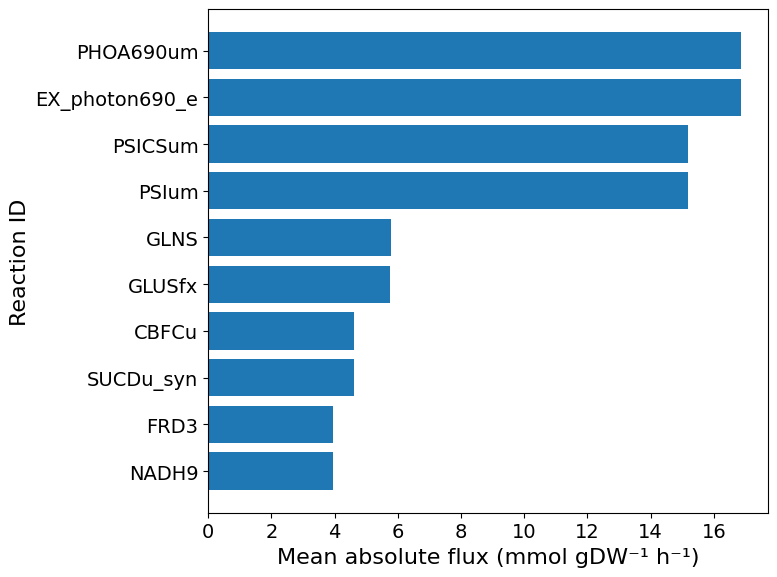

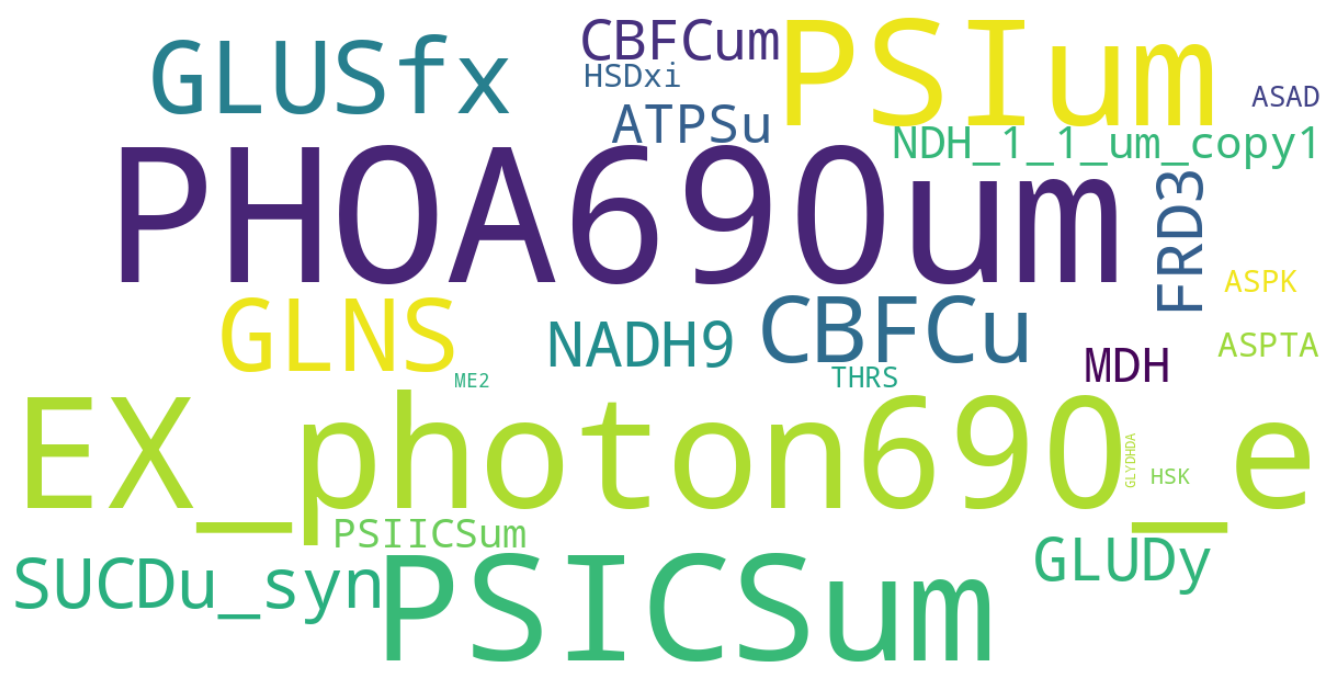


Processing PHB_SYN_UB = 1000.0


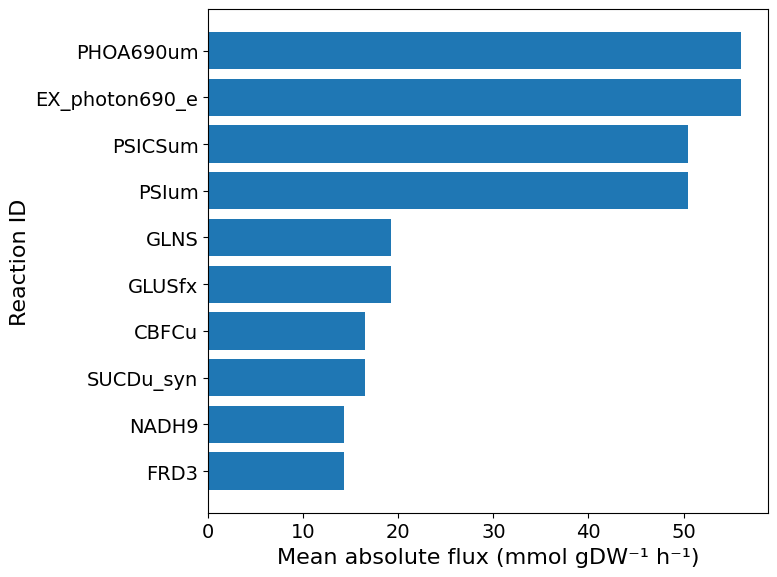

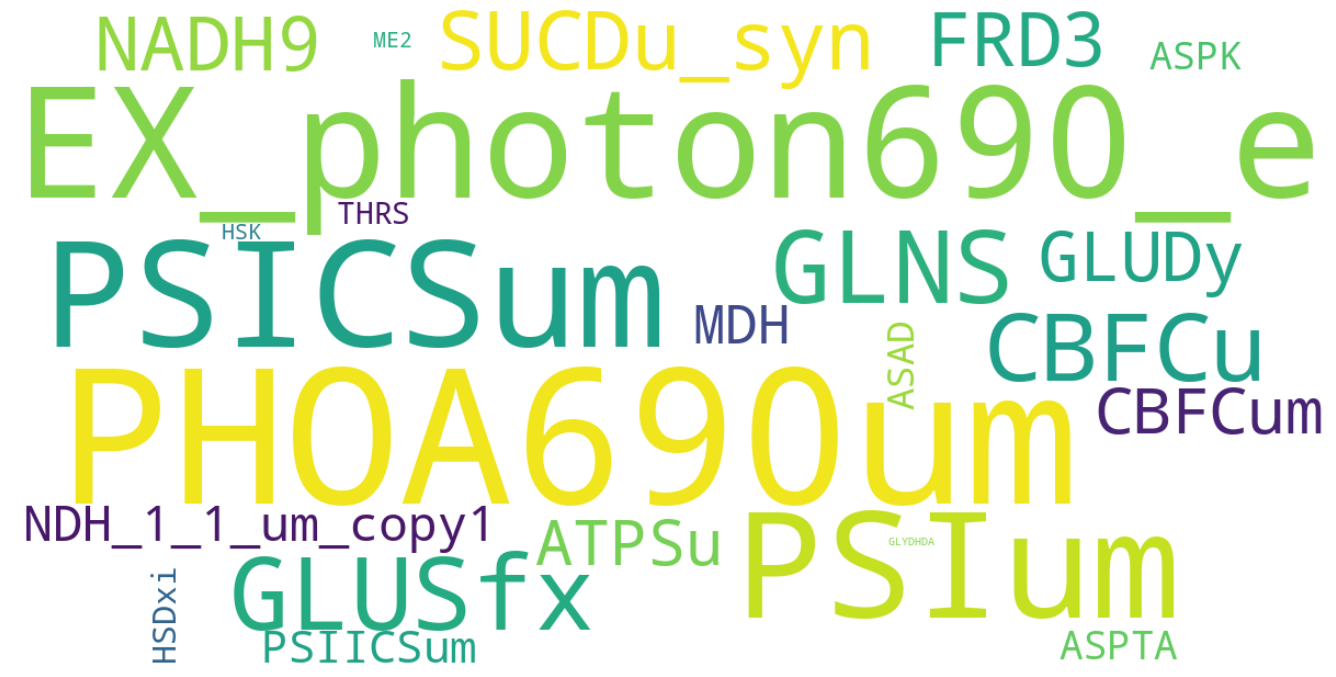

In [ ]:
from wordcloud import WordCloud
from collections import Counter

TOP_K = 10
PHB_SYN_UB_VALUES = [0.3978, 1000.0] #[0.0167, 1.0]

# ============================================================
# Reaction → Subsystem mapping (from GEM) This output is not so clean since the subsystems are not named consistenly
# ============================================================

#flux_subsystem = {
#    rxn.id: rxn.subsystem if rxn.subsystem else "Other"
#    for rxn in model_phb2.reactions
#}

for PHB_SYN_UB in PHB_SYN_UB_VALUES:

    print(f"\nProcessing PHB_SYN_UB = {PHB_SYN_UB}")
    PHB_SYN_TAG = f"{PHB_SYN_UB:g}"

    # --------------------------------------------------
    # 1. Load Top-20 intersection fluxes
    # --------------------------------------------------
    df = pd.read_csv(
        PHB_GEM_AUGMENTATION_DIR / f"03_Buitron_dataset_top20_union_fluxes_aug_{PHB_SYN_TAG}.csv"
    )

    # rows   -> FBA runs
    # columns-> reactions (top-20 intersection)
    n_runs = df.shape[0]

    # --------------------------------------------------
    # 2. Flux-weighted, normalized reaction relevance
    # --------------------------------------------------
    flux_scores = (
        df.abs()
          .sum(axis=0)          # sum |flux| across runs
          .div(n_runs)          # normalize by number of runs
          .sort_values(ascending=False)
    )

    score_df = (
        flux_scores
        .reset_index()
        .rename(columns={"index": "reaction_id", 0: "mean_abs_flux"})
    )

    score_df_top = score_df.head(TOP_K)

    # ==================================================
    # PART A — REACTION-LEVEL PLOTS
    # ==================================================

    # --------------------------------------------------
    # Histogram (reactions)
    # --------------------------------------------------
    plt.rcParams.update({'font.size': 14})
    plt.figure(figsize=(8, 6))
    plt.barh(
        score_df_top["reaction_id"][::-1],
        score_df_top["mean_abs_flux"][::-1]
    )
    plt.xlabel("Mean absolute flux (mmol gDW⁻¹ h⁻¹)", fontsize= 16)
    plt.ylabel("Reaction ID", fontsize= 16)
    #plt.title(f"Flux-weighted reaction relevance")
    plt.tight_layout()

    for ext in ["pdf", "png", "tiff"]:
      plt.savefig(
          PHB_FIGURES_DIR / f"03_histogram_flux_weighted_reactions_aug_PHB_SYN_UB_{PHB_SYN_TAG}.{ext}",
          dpi=300,
          bbox_inches="tight",
      )
    plt.show()

    # --------------------------------------------------
    # Wordcloud (reactions)
    # --------------------------------------------------
    wc_rxn = WordCloud(
        width=1200, height=600,
        background_color="white",
        max_words=100
    ).generate_from_frequencies(flux_scores.to_dict())

    plt.figure(figsize=(14, 7))
    plt.imshow(wc_rxn, interpolation="bilinear")
    plt.axis("off")
    plt.tight_layout()

    for ext in ["pdf", "png", "tiff"]:
      plt.savefig(
          PHB_FIGURES_DIR / f"03_wordcloud_flux_weighted_reactions_aug_PHB_SYN_UB_{PHB_SYN_TAG}.{ext}",
          dpi=300,
          bbox_inches="tight",
      )
    plt.show()


## *FBA vs pFBA yield boxplots

PHB_SYN_UB_VALUE:0.3978
543
543
Mann–Whitney U test: U=89333.00, p=0.0000, significance=***


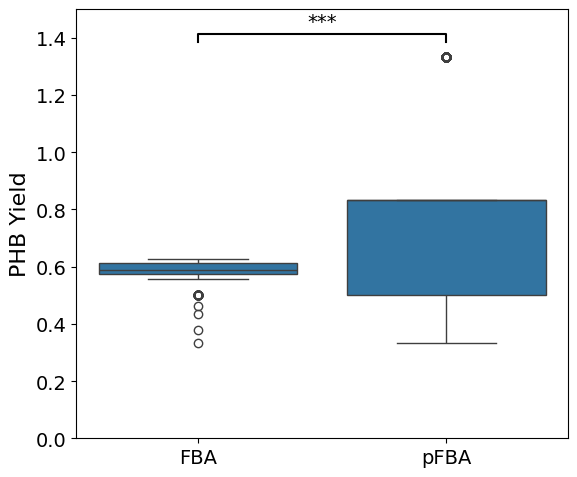

DONE — PHB Yield
PHB_SYN_UB_VALUE:1000
543
543
Mann–Whitney U test: U=148852.00, p=0.7824, significance=ns


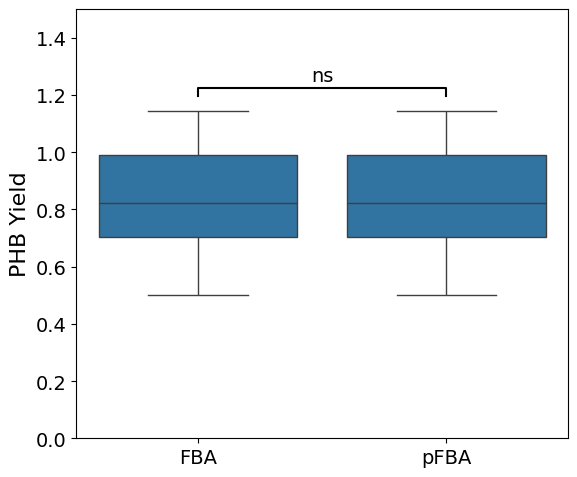

DONE — PHB Yield


In [ ]:
# Make boxplots of FBA vs pFBA and Mann-Whitney U-test


PHB_SYN_UB_VALUES = [0.3978, 1000] #[0.0167, 1.0]
for PHB_SYN_UB in PHB_SYN_UB_VALUES:

  print(f"PHB_SYN_UB_VALUE:{PHB_SYN_UB}")

  PHB_SYN_TAG = f"{PHB_SYN_UB:g}"  # used for filenames

  df_final = pd.read_csv(PHB_GEM_AUGMENTATION_DIR / f"03_Buitron2025_dataset_augmented_VFAs_phb_with_cost_n2_full_{PHB_SYN_TAG}.csv")


  comparison_groups = {
      "PHB Yield": [
          "PHB_yield_con",
          "PHB_yield_con_pfba"
      ]
  }


  # Function to convert p-value to significance asterisks
  def p_to_asterisks(p):
      if p < 0.001:
          return "***"
      elif p < 0.01:
          return "**"
      elif p < 0.05:
          return "*"
      else:
          return "ns"

  for metric, cols in comparison_groups.items():

      fba_col, pfba_col = cols

      if all(col in df_final.columns for col in cols):

          # -----------------------------------------------------
          # Select columns
          # -----------------------------------------------------
          df_tmp = df_final[[fba_col, pfba_col]].copy()
          df_tmp.columns = ["FBA", "pFBA"]

          df_tmp.replace([np.inf, -np.inf], np.nan, inplace=True)

          # -----------------------------------------------------
          # Reshape for seaborn
          # -----------------------------------------------------
          df_plot = df_tmp.melt(
              var_name="regime",
              value_name="value"
          )

          # -----------------------------------------------------
          # Mann–Whitney U test
          # -----------------------------------------------------
          group1 = df_tmp["FBA"].dropna()
          print(len(group1))
          group2 = df_tmp["pFBA"].dropna()
          print(len(group2))


          stat, p_value = mannwhitneyu(group1, group2, alternative="two-sided")
          sig = p_to_asterisks(p_value)
          print(f"Mann–Whitney U test: U={stat:.2f}, p={p_value:.4f}, significance={sig}")

          # -----------------------------------------------------
          # Plot
          # -----------------------------------------------------
          plt.figure(figsize=(6, 5))
          plt.ylim(0, 1.5)

          sns.boxplot(
              data=df_plot,
              x="regime",
              y="value"
          )

          # -----------------------------------------------------
          # Annotate significance (asterisk) between boxes
          # -----------------------------------------------------
          y_max = df_plot["value"].max()
          x1, x2 = 0, 1
          y, h = y_max + 0.05, 0.03  # line height
          plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='black')
          plt.text((x1+x2)*0.5, y+h+0.01, sig, ha='center', va='bottom', fontsize=14)

          # -----------------------------------------------------
          # Styling
          # -----------------------------------------------------
          plt.ylabel(metric, fontsize=16)
          plt.xlabel("", fontsize=16)

          plt.xticks(fontsize=14)
          plt.yticks(fontsize=14)

          plt.tight_layout()

          # -----------------------------------------------------
          # Save figure
          # -----------------------------------------------------

          for ext in ["pdf", "png", "tiff"]:
            plt.savefig(
                PHB_FIGURES_DIR / f"03_FBA_vs_pFBA_PHB_yield_{PHB_SYN_TAG}.{ext}",
                dpi=300,
                bbox_inches="tight",
            )

          plt.show()

          print(f"DONE — {metric}")
